# Spatial Data

Spatial data identifies the geographic location of features and boundaries in a digital format. This data can be mapped and is stored as coordinates and topology that can be used for mapping or analyzing the spatial relationship between features. This notebook is a quick introduction to the most common file format and Python tools for working with spatial data.

# File types
There are two main file types we will work with.

1. One is called a shapefile. It is a propriertary data format that stores geographic data and other characteristics together. Go to the Census  [website](https://www.census.gov/cgi-bin/geo/shapefiles/index.php)  and download the Census tract map for the state of TN.
2. We will work with that for this example.
Lat/Long data comes with latitude and longitude coordinates and some information about what is happening at that point.

## Coordinate Reference Systems (CRS)

A crucial aspect of spatial data is its Coordinate Reference System (CRS), which defines how coordinates are mapped to locations on Earth. The Earth is a sphere, but print and digital maps are usually displayed in 2-dimensions. The CRS describes how we choose to project our data onto 2D. It is important to make sure all the data in a project uses the same CRS so that it any distortion is constant across data sources. 


![Image title](https://media.opennews.org/cache/06/37/0637aa2541b31f526ad44f7cb2db7b6c.jpg)

# Import packages and paths

Import the spatial data packages and define the path to the data we will need. I used the Anaconda Prompt, Anaconda's command line style interface. I installed the package and its dependencies using the code "conda install --channel conda-forge geopandas", but there are lots of ways to do it. 

In [6]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [7]:
import geopandas as gpd
#$import contextily as ctx
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
shape_file = "tl_2024_47_tract.shp"

# Census data
We are going to use two sources of Census data. Tract level data on race and income from the API and spatial data from the Census website. Download the census tract level shapefile for your state. Then write an API call to collect tract level sociodemographics and put them in a dataframe. 

In [9]:
url="https://api.census.gov/data/2015/acs/acs5?key=7531444b3c2c222bdf805c790c79ccef8ac6f7b2&get=NAME,B02001_001E,B02001_003E,B01001I_001E,B02001_002E,B19013_001E,B06012_002E&for=tract:*&in=state:47%20county:*"
r=requests.get(url)        
data = pd.read_json(r.text)                          # put the data in a string called "data"

df_census = pd.DataFrame(data=data)                  # create a data frame
df_census.columns = df_census.iloc[0]                               # create column names from first row 
df_census = df_census[1:]                                           # now delete the first row 
df_census['B19013_001E'] = df_census['B19013_001E'].astype(float)   # convert individual variable to numeric
df_census['B19013_001E'] = df_census['B19013_001E'].replace(-666666666,np.NaN)       # replace supressed data with missing

df_census.rename(columns = {'B19013_001E':'MedianIncome', 'B02001_001E':'Population', 'B02001_003E':'Black', 'B01001I_001E':'Hispanic', 'B06012_002E':'Poverty'}, inplace = True) 
df_census['Population'] = df_census['Population'].astype(float)   # convert individual variable to numeric
df_census['Black'] = df_census['Black'].astype(float)   # convert individual variable to numeric
df_census['Poverty'] = df_census['Poverty'].astype(float)   # convert individual variable to numeric
df_census['Black_Percent']=df_census['Black']/df_census['Population']
df_census['Poverty_Rate']=df_census['Poverty']/df_census['Population']


/var/folders/bx/nqjcpmxx6x96dkrkb4lshl4w0000gn/T/ipykernel_59587/2068647600.py:3: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(r.text)                          # put the data in a string called "data"


EPSG:4269


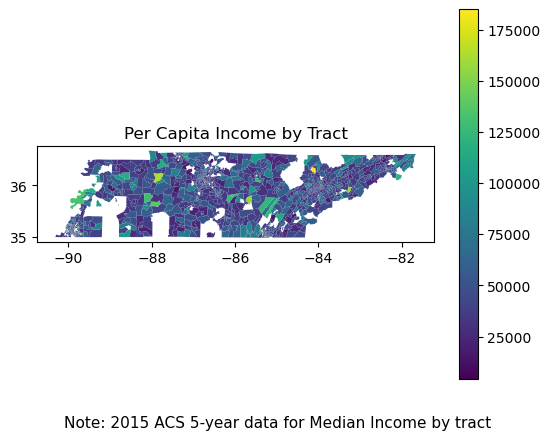

In [10]:
# Load spatial data
sdf=gpd.read_file(shape_file)                                # Create a spatial data frame
sdf=sdf.rename(columns={"STATEFP":"STATE", "COUNTYFP": "COUNTY", "TRACTCE":"TRACT"})    # Clean up variable names to match
gdf_tracts=sdf.join(df_census, rsuffix='_census')            # Join by common variables (state, county, tract)
gdf_tracts.plot(column='MedianIncome', legend=True)           # Plot tracts colored by column
plt.title("Per Capita Income by Tract")                      # Figure title
plt.figtext(0.5, 0.01, "Note: 2015 ACS 5-year data for Median Income by tract" ,ha="center",fontsize=11)                               # Figure note

print(gdf_tracts.crs)
plt.savefig('TN_poverty.png')                                # Save a copy of the image

# Powerplant data
Now read in the power plant data and convert it to geographic data using the lat/long. 

In [12]:
##Read in power plant data and restrict to the state in question ##
plants="2___Plant_Y2020.xlsx"        # Replace with your path
df_plants =pd.read_excel(plants, header=1)  
df_plants = df_plants.drop(df_plants.index[df_plants.State != 'TN'])
df_plants['Latitude'] = df_plants['Latitude'].apply(pd.to_numeric, errors='coerce')      # Convert power plant data to numeric
df_plants['Longitude']  = df_plants['Longitude'].apply(pd.to_numeric, errors='coerce')      # Convert power plant data to numeric
gdf_plants = gpd.GeoDataFrame(df_plants, geometry=gpd.points_from_xy(df_plants.Longitude, df_plants.Latitude), crs="EPSG:4269")
gdf_plants = gdf_plants.dropna(axis=1)
gdf_plants

,Utility ID,Utility Name,Plant Code,Plant Name,Street Address,City,State,Zip,County,Latitude,...,FERC Small Power Producer Status,FERC Exempt Wholesale Generator Status,Transmission or Distribution System Owner,Transmission or Distribution System Owner ID,Transmission or Distribution System Owner State,Grid Voltage (kV),Grid Voltage 2 (kV),Grid Voltage 3 (kV),Energy Storage,geometry
1678,18642,Tennessee Valley Authority,3393,Allen,2574 Plant Rd.,Memphis,TN,38109,Shelby,35.074087,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-90.14868 35.07409)
1679,18642,Tennessee Valley Authority,3394,Apalachia,899 Powerhouse Rd,Reliance,TN,37369,Polk,35.167712,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-84.2956 35.16771)
1680,18642,Tennessee Valley Authority,3395,Boone Dam,301 Boone Dam Rd,Kingsport,TN,37663,Sullivan,36.440300,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-82.4381 36.4403)
1681,18642,Tennessee Valley Authority,3396,Bull Run,1265 EDGEMOOR RD.,Clinton,TN,37716,Anderson,36.021100,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-84.1567 36.0211)
1682,18642,Tennessee Valley Authority,3397,Cherokee Dam,450 POWER HOUSE RD,Rudledge,TN,37861,Jefferson,36.168176,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-83.49768 36.16818)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11441,63346,"Tate and Lyle Ingredients, LLC",63632,Tate & Lyle Loudon Plant,198 Blair Bend Drive,Loudon,TN,37774,Loudon,35.735092,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-84.3193 35.73509)
11524,63418,Elora Solar,63719,Elora Solar,7 Terry Dunavan Rd,Elora,TN,37328,Lincoln,35.060000,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-86.34 35.06)
12045,18642,Tennessee Valley Authority,64255,Vonore Battery Energy Storage System,TBD,Vonore,TN,37885,Monroe,35.615430,...,N,N,Tennessee Valley Authority,18642,TN,13,,,Y,POINT (-84.27489 35.61543)
12276,64084,OE_TN1,64507,OETN1,TBD,Obion,TN,38261,Obion,36.386380,...,N,N,Tennessee Valley Authority,18642,TN,161,,,N,POINT (-88.99194 36.38638)


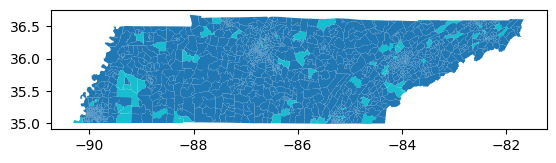

<Figure size 640x480 with 0 Axes>

In [13]:
# Spatial join
## Add your spatial join code here            
gdf_plants_tracts=gpd.sjoin(gdf_tracts, gdf_plants, how="left")

## Create an indicator for tracts with a plant
gdf_plants_tracts['HasPlant']=gdf_plants_tracts['Plant Code'].notna()
gdf_plants_tracts.plot(column='HasPlant')
plt.show()
plt.savefig('TN_plants_tract.png')                                # Save a copy of the image

In [14]:
# Calculate summary statistics by Group
gdf_plants_tracts.groupby(['HasPlant'])[['MedianIncome','Black_Percent', 'Poverty_Rate']].mean()


,MedianIncome,Black_Percent,Poverty_Rate
HasPlant,,,
False,47186.169744,0.185141,0.184333
True,50066.366197,0.167400,0.169242


/var/folders/bx/nqjcpmxx6x96dkrkb4lshl4w0000gn/T/ipykernel_59587/823307787.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_plant_buffer['geometry'] = gdf_plants.geometry.buffer(0.03)


  STATE COUNTY   TRACT        GEOID               GEOIDFQ    NAME  \
0    47    073  050501  47073050501  1400000US47073050501  505.01   
1    47    073  050601  47073050601  1400000US47073050601  506.01   
2    47    073  050602  47073050602  1400000US47073050602  506.02   
3    47    073  050502  47073050502  1400000US47073050502  505.02   
4    47    073  050503  47073050503  1400000US47073050503  505.03   

              NAMELSAD  MTFCC FUNCSTAT     ALAND  ...  \
0  Census Tract 505.01  G5020        S  83355996  ...   
1  Census Tract 506.01  G5020        S  23847669  ...   
2  Census Tract 506.02  G5020        S  23386547  ...   
3  Census Tract 505.02  G5020        S  32873931  ...   
4  Census Tract 505.03  G5020        S  17050728  ...   

   FERC Small Power Producer Status FERC Exempt Wholesale Generator Status  \
0                               NaN                                    NaN   
1                               NaN                                    NaN   
2       

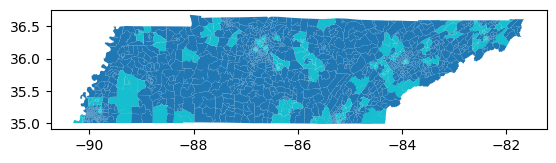

<Figure size 640x480 with 0 Axes>

In [15]:
# Create a buffer around plants to capture community impacts
gdf_plant_buffer=gdf_plants
gdf_plant_buffer['geometry'] = gdf_plants.geometry.buffer(0.03)
gdf_buffers_tracts=gpd.sjoin(gdf_tracts, gdf_plant_buffer, how="left")

## Create an indicator for tracts with a plant
gdf_buffers_tracts['HasPlant']=gdf_buffers_tracts['Plant Code'].notna()
print(gdf_buffers_tracts.head())
gdf_buffers_tracts.plot(column='HasPlant')
plt.show()
plt.savefig('TN_buffers_tract.png')                                # Save a copy of the image

In [16]:
# Calculate summary statistics by Group
gdf_buffers_tracts.groupby(['HasPlant'])[['MedianIncome','Black_Percent', 'Poverty_Rate']].mean()

,MedianIncome,Black_Percent,Poverty_Rate
HasPlant,,,
False,46838.784364,0.188208,0.185547
True,49299.638889,0.170611,0.174626
